In [2]:
# استيراد المكتبات اللي هنحتاجها
import numpy as np
import matplotlib.pyplot as plt
# إيه هو matplotlib؟
# هي مكتبة الرسم. بتستخدمها عشان:

# تشوف الصور من الداتا
# ترسم منحنيات الـ Loss والـ Accuracy
#تعرض النتايج بصرياً
import tensorflow as tf

# إيه هو TensorFlow؟
# ده الـ "محرك" اللي بيشغّل الشبكة العصبية. بيعمل كل العمليات الرياضية الضخمة اللي بتحصل جوا الـ Neural Network (الضرب في المصفوفات، حساب الـ gradients، إلخ).
# عملته Google وهو من أشهر مكتبات الـ AI في العالم.
# لو شيلته؟ مش هينفع تبني أي شبكة عصبية خالص — ده الأساس كله
from tensorflow import keras
# إيه هو Keras؟
# Keras هو واجهة سهلة فوق TensorFlow.
# تخيل كده:

# TensorFlow = محرك العربية (قوي بس معقد)
# Keras = عجلة القيادة والبيدالات (بسيطة وسهلة الاستخدام)

# بدل ما تكتب 100 سطر رياضيات معقدة في TensorFlow، Keras بتخليك تبني الشبكة في 5 أسطر.
# لو شيلته؟ هيظهر error في كل سطر بيستخدم keras.
from tensorflow.keras import layers
# إيه هي layers؟
# دي الـ "طبقات" اللي بنبني منها الشبكة العصبية.
# زي ما البناية بتتبنى من طوب، الشبكة العصبية بتتبنى من layers. كل layer بتاخد input وبتعمل حاجة عليه وبتطلع output.
# هنستخدمها لما نقول مثلاً:
# pythonlayers.Dense(128)  # طبقة فيها 128 خلية عصبية
# لو شيلته؟ مش هتقدر تضيف أي طبقات للشبكة

print("TensorFlow version:", tf.__version__)
print("All libraries were successfully downloaded")


# numpy       → للتعامل مع الأرقام والمصفوفات
# matplotlib  → للرسم والتصور
# tensorflow  → المحرك الأساسي للشبكة العصبية
# keras       → واجهة سهلة فوق tensorflow
# layers      → الطبقات اللي بنبني منها الشبكة

TensorFlow version: 2.20.0
All libraries were successfully downloaded


In [3]:
#هنا تحميل الداتا  وتجهيزها
# Load MNIST dataset
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()#دى اسم المكتبة ال هحمل منها البيانات

# Check data shapes
print("Training data shape:", X_train.shape) #(60000, 28, 28)
print("Training labels shape:", y_train.shape) #(60000,)
print("Test data shape:", X_test.shape) #(10000, 28, 28)
print("Test labels shape:", y_test.shape) #(10000,)

# keras.datasets.mnist.load_data()	جيبلي بيانات MNIST من النت
# (x_train, y_train)	صور التدريب + حلولهم
# (x_test, y_test)	صور الاختبار + حلولهم
# .shape	قوللي كل حاجة فيها كام عنصر
# (60000, 28, 28)	60 ألف صورة، كل صورة 28×28 بكسل
# len(y_train)	كم رقم عندي في قائمة الحلول
#⚠️ لاحظ إن الصور مش ملونة، عشان كفاية بُعدان (طول × عرض). لو كانت ملونة هيكون الشكل (60000, 28, 28, 3) عشان القناة الثالثة للألوان (RGB).
##############
# Step 2: Data Preprocessing - Scaling
# We divide by 255 to normalize pixel values from [0, 255] to [0.0, 1.0]
X_train = X_train / 255
X_test = X_test / 255.0

print("Max value after scaling:", X_train.max())
print("Min value after scaling:", X_train.min())



# إيه اللي بيحصل هنا؟
# قبل الـ Scaling:
# كل pixel قيمته بين 0 و 255
# 0   = أسود تماماً ⬛
# 255 = أبيض تماماً ⬜
# 128 = رمادي في النص
# بعد الـ Scaling:
# بنقسم على 255 فتبقى القيم بين 0.0 و 1.0
# 0   → 0.0
# 255 → 1.0
# 128 → 0.50

# ليه بنعمل ده؟
# سببين مهمين:
# السبب الأول: الشبكة العصبية بتتعلم أحسن بأرقام صغيرة
# تخيلي إنك بتحسبي حاجة وعندك أرقام كبيرة جداً زي 200، 178، 255 — الحسابات بتبقى صعبة وبطيئة. لو الأرقام بين 0 و 1 الحسابات بتبقى أسهل وأسرع.
# السبب الثاني: كل الـ features تبقى في نفس النطاق
# لو عندك features بعضها كبير وبعضها صغير، الشبكة هتاخد بالها من الكبير وتتجاهل الصغير — ده غلط.




11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Max value after scaling: 1.0
Min value after scaling: 0.0


In [4]:
# Flatten - تحويل الصورة من جدول لخط واحد
X_train_flat = X_train.reshape(60000, 784)
X_test_flat = X_test.reshape(10000, 784)

print("Data format before Flatten:", X_train.shape)
print("Data format after Flatten:", X_train_flat.shape)

Data format before Flatten: (60000, 28, 28)
Data format after Flatten: (60000, 784)


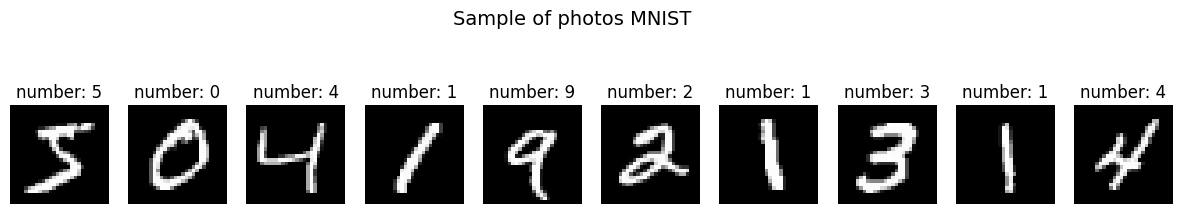

In [5]:
# نشوف 10 صور من الداتا
plt.figure(figsize=(15, 3))
# ده بيعمل لوحة رسم فاضية.
# figsize=(15, 3) يعني:

# عرض اللوحة = 15
# ارتفاع اللوحة = 3

# لو غيرتي الأرقام دي هتلاقي اللوحة بتكبر وبتصغر

for i in range(10):
# ده loop بيكرر الكود 10 مرات.
# i بياخد القيم: 0، 1، 2، 3، 4، 5، 6، 7، 8، 9
# يعني بيقول "كرر الكود الجاي 10 مرات



    plt.subplot(1, 10, i+1)
# ده بيقسم اللوحة لـ 10 أماكن جنب بعض.
# 1   →  صف واحد بس
# 10  →  10 عمود
# i+1 →  أنا دلوقتي في المكان رقم كام
# يعني اللوحة بتتقسم كده:
# [ 1 ][ 2 ][ 3 ][ 4 ][ 5 ][ 6 ][ 7 ][ 8 ][ 9 ][ 10 ]
# بنقول




    plt.imshow(X_train[i], cmap='gray')
# imshow = اعرض الصورة

# X_train[i] = الصورة رقم i من الداتا
# cmap='gray' = اعرضها بالأبيض والأسود

# لو شيلتي cmap='gray' هتتعرض بألوان غريبة مش أبيض وأسود.



    plt.title(f"number: {y_train[i]}")

# ده بيحط عنوان فوق كل صورة بيقول الرقم اللي في الصورة دي.
# y_train[i] = الإجابة الصح للصورة رقم i
# يعني فوق كل صورة هيكتب مثلاً "رقم: 5"


    plt.axis('off')
#     ده بيشيل الأرقام اللي على جنبات الصورة (المحاور)
# بدونه هتشوفي أرقام زي 0، 5، 10، 25 على جنب كل صورة وهتبقى شكلها وحش


plt.suptitle("Sample of photos MNIST", fontsize=14)
#ده عنوان كبير لكل اللوحة (مش لصورة واحدة).
#fontsize=14 = حجم الخط
plt.show()




# plt.figure()     →  افتح لوحة رسم
# for i in range() →  كرر 10 مرات
# plt.subplot()    →  قسم اللوحة لأماكن
# plt.imshow()     →  ارسم الصورة
# plt.title()      →  اكتب الإجابة فوقيها
# plt.axis('off')  →  شيل المحاور
# plt.suptitle()   →  عنوان كبير للوحة كلها
# plt.show()       →  اعرض كل حاجة

In [6]:
## Step 3: Build the Neural Network Model (MLP)
model = keras.Sequential([
    keras.Input(shape=(784,)),
#     ده الـ Input Layer.

# يعني الشبكة هتستقبل بيانات شكلها 784 قيمة.

# ليه 784 ؟

# غالبًا لأنك شغال على Dataset زي MNIST.

# صور الـ MNIST حجمها:

# 28 × 28

# ولما نفرد الصورة:

# 28 × 28 = 784

# فتتحول الصورة من Matrix إلى Vector.

# معنى shape=(784,)

# يعني:
# كل Sample داخل فيه 784 Feature.

# الفاصلة مهمة جدًا.

# لأن Python بتميز الـ Tuple كده:

# (784,)




    layers.Dense(128, activation='relu'),#الأولى بتلم الملامح البسيطة زي الحروف المستقيمة،

# دي Hidden Layer.

# معنى Dense

# Dense يعني:
# كل Neuron متوصل بكل Neuron في الطبقة اللي قبله.

# Fully Connected Layer.

# معنى 128

# عدد الـ Neurons في الطبقة = 128.

# يعني الطبقة فيها 128 خلية عصبية.

# معنى activation='relu'

# دي Activation Function.

# اسمها:
# ReLU

# شكلها رياضيًا:

# f(x)=max(0,x)

# بتعمل ايه؟

# لو الرقم سالب:
# تخليه 0

# لو موجب:
# تسيبه زي ما هو.

# ليه بنستخدم ReLU ؟

# لأنها:

# سريعة
# تقلل مشكلة Vanishing Gradient
# تخلي الشبكة تتعلم Non-linear patterns


    layers.Dense(64, activation='relu'),
#     الفرق بينها وبين اللي قبلها؟

# هنا عدد الـ neurons = 64 بدل 128.

# يعني الشبكة بدأت تضغط المعلومات تدريجيًا.

# الفكرة العامة

# الطبقات الأولى:
# تتعلم Features كتير.

# الطبقات الأعمق:
# تستخلص أهم Features.

    layers.Dense(10, activation='softmax')
#     دي Output Layer.

# معنى 10

# لأن غالبًا عندك 10 Classes.

# مثلاً أرقام:
# 0 → 9

# معنى softmax

# دي Activation Function خاصة بالتصنيف متعدد الفئات.

# بتحول الأرقام لاحتمالات.

# مثال:

# قبل Softmax:

# [2.1, 1.3, 5.7]

# بعد Softmax:

# [0.02, 0.01, 0.97]

# يعني:
# الموديل متأكد بنسبة 97% من الفئة الثالثة.
])

model.summary()



# نقطة مهمة جداً للدفاع (فهم الـ Summary):
# لما شغلت model.summary()، طبعلك جدول. فيه عامود اسمه Param # (عدد الباراميترات).
# لو سألك بروفسورك: "ليه أول طبقة فيها 100,480 باراميتر؟"
# إنت لازم تعرف تجاوب: لأن كل نيورون في الطبقة الأولى بيتصل بكل الـ 784 بكسل اللي في الطبقة اللي قبلها (784 × 128 = 100,352) + لكل نيورون بيس (Bias) (128 × 1 = 128). المجموع = 100,480.
# (احفظ القاعدة دي، هتدعي عليا لما تيجي تسألني إزاي أحسبهم).



# ازاى الشبكة بتشتغل فعليًا؟

# الصورة تدخل →

# تعدي على أول Layer →

# ReLU تشغل القيم المهمة →

# Layer تانية تستخلص Features أقوى →

# Softmax يطلع احتمالات →

# الموديل يقرر الرقم النهائي.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Step 4: Compile the Model
 model.compile(                               #ده بيقول للموديل "استعد للتدريب" وبيحدد له 3 حاجات:
    optimizer='adam',
#                                               يعني ايه Optimizer ؟

# الـ Optimizer هو المسؤول عن:
# تعديل الأوزان Weights أثناء التدريب.

# يعني هو اللي يخلي الشبكة:
# تتعلم من أخطائها.

# الفكرة الأساسية

# الشبكة في البداية بتكون عشوائية.

# فتتوقع غلط.

# الـ Optimizer يشوف الغلط →
# ويعدل الأوزان →
# عشان يقلل الغلط تدريجيًا.

# معنى adam

# Adam ده أشهر Optimizer تقريبًا.

# اسمه الكامل:

# Adaptive Moment Estimation

# ليه الناس بتحبه؟

# لأنه:

# سريع
# مستقر
# شغال كويس في أغلب المشاكل
# مش محتاج ضبط كتير
# الفكرة الداخلية بتاعته

# Adam بيستخدم:

# Momentum
# Adaptive Learning Rate

# يعني:

# ياخد في اعتباره اتجاه التعلم السابق
# ويغير سرعة التعلم تلقائيًا
    loss='sparse_categorical_crossentropy',

#                                               يعني ايه Loss ؟

# الـ Loss Function هي:
# الدالة اللي بتحسب مقدار الخطأ.

# يعني:
# "الموديل غلط قد ايه؟"

# كل ما الـ Loss يقل

# يبقى الموديل بيتعلم صح.

# معنى categorical

# يعني عندك:
# تصنيف Classification

# مثلاً:
# 0 → 9

# معنى crossentropy

# دي معادلة رياضية تقيس الفرق بين:

# التوقع الحقيقي
# وتوقع الموديل
# ليه sparse_categorical_crossentropy تحديدًا؟

# لأن الـ Labels عندك غالبًا بالشكل ده:

# 5
# 2
# 9
# 1

# يعني أرقام عادية.

# مش One-Hot Encoded.

# الفرق المهم جدًا
# لو البيانات كده:
# 7

# نستخدم:

# sparse_categorical_crossentropy
# لو البيانات كده:
# [0,0,0,0,0,0,0,1,0,0]

# نستخدم:

# categorical_crossentropy
# المعادلة الرياضية

# L=−∑
# i=1
# n
# 	​

# y
# i
# 	​

# log(
# y
# ^
# 	​

# i
# 	​

# )

# معناها ببساطة

# الدالة دي:
# تقارن بين الإجابة الحقيقية واحتمالات الموديل.

# لو الموديل واثق في الإجابة الصح:
# الـ Loss يبقى صغير.

# لو واثق في إجابة غلط:
# الـ Loss يبقى كبير جدًا.

    metrics=['accuracy']
#                                               يعني ايه Metrics ؟

# دي مقاييس تقييم الأداء.

# يعني:
# هنراقب ايه أثناء التدريب؟

# معنى accuracy

# الدقة.

# يعني:
# كام توقع صح من إجمالي التوقعات.

# مثال

# لو:
# 100 صورة

# والموديل صح في 92

# يبقى:

# Accuracy=
# 100
# 92
# 	​

# =0.92

# يعني:
# 92%



)

print("Compilation done successfully ✅")

Compilation done successfully ✅


In [8]:
# Step 5: Train the Model
history = model.fit(
    X_train_flat, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("Training done successfully ✅")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9192 - loss: 0.2721 - val_accuracy: 0.9547 - val_loss: 0.1504
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9652 - loss: 0.1164 - val_accuracy: 0.9649 - val_loss: 0.1164
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9751 - loss: 0.0802 - val_accuracy: 0.9680 - val_loss: 0.1074
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9814 - loss: 0.0601 - val_accuracy: 0.9720 - val_loss: 0.0914
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9845 - loss: 0.0471 - val_accuracy: 0.9699 - val_loss: 0.1097
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9879 - loss: 0.0372 - val_accuracy: 0.9731 - val_loss: 0.0952
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9896 - loss: 0.0304 - val_accuracy: 0.9708 - val_loss: 0.1070
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9927 - loss: 0.0235 - 

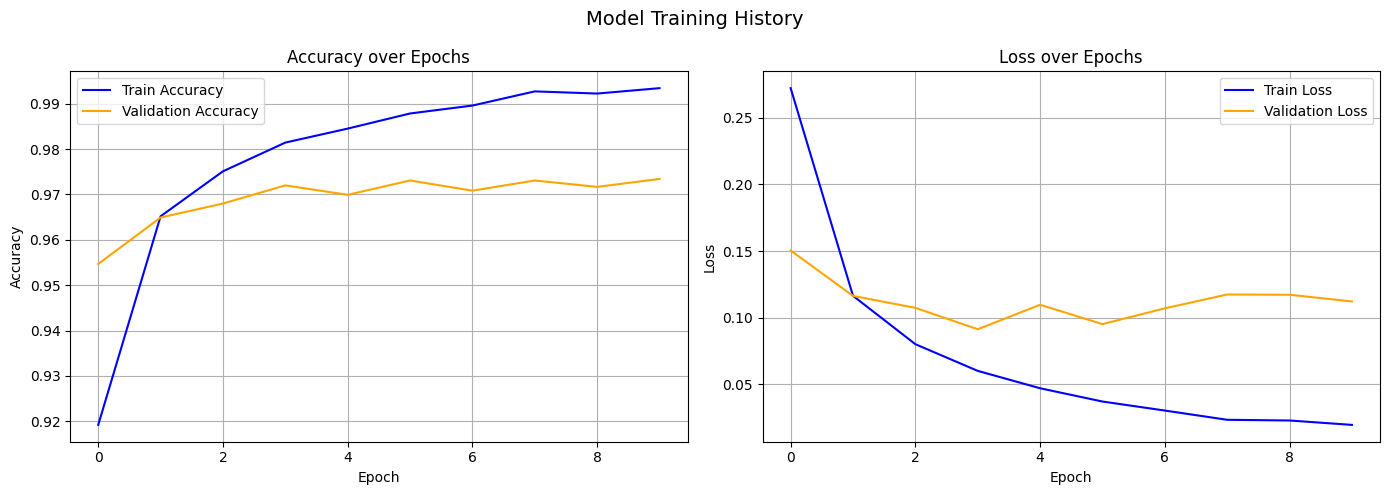

In [9]:
# Step 6: Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(history.history['loss'], label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Model Training History', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Step 7: Evaluate the Model on Test Data
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test, verbose=0)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Test Loss:     0.0923
Test Accuracy: 0.9759 (97.59%)


In [11]:
# Experiment 2: sigmoid instead of relu
model2 = keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(128, activation='sigmoid'),
    layers.Dense(64, activation='sigmoid'),
    layers.Dense(10, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train_flat, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

test_loss2, test_accuracy2 = model2.evaluate(X_test_flat, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy2*100:.2f}%")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8646 - loss: 0.5397 - val_accuracy: 0.9303 - val_loss: 0.2383
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9405 - loss: 0.2028 - val_accuracy: 0.9496 - val_loss: 0.1738
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9575 - loss: 0.1444 - val_accuracy: 0.9593 - val_loss: 0.1387
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9674 - loss: 0.1096 - val_accuracy: 0.9647 - val_loss: 0.1192
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9750 - loss: 0.0862 - val_accuracy: 0.9628 - val_loss: 0.1186
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9797 - loss: 0.0688 - val_accuracy: 0.9693 - val_loss: 0.0996
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9840 - loss: 0.0557 - val_accuracy: 0.9719 - val_loss: 0.0913
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9875 - loss: 0.0450 - 

In [12]:
# Experiment 3: More Neurons (256 → 128)
model3 = keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train_flat, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

test_loss3, test_accuracy3 = model3.evaluate(X_test_flat, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy3*100:.2f}%")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9315 - loss: 0.2276 - val_accuracy: 0.9642 - val_loss: 0.1238
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9720 - loss: 0.0913 - val_accuracy: 0.9709 - val_loss: 0.0998
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9794 - loss: 0.0636 - val_accuracy: 0.9734 - val_loss: 0.0867
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9857 - loss: 0.0452 - val_accuracy: 0.9655 - val_loss: 0.1253
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9886 - loss: 0.0353 - val_accuracy: 0.9745 - val_loss: 0.0929
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9901 - loss: 0.0299 - val_accuracy: 0.9769 - val_loss: 0.0891
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9910 - loss: 0.0252 - val_accuracy: 0.9763 - val_loss: 0.1018
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9939 - loss: 0

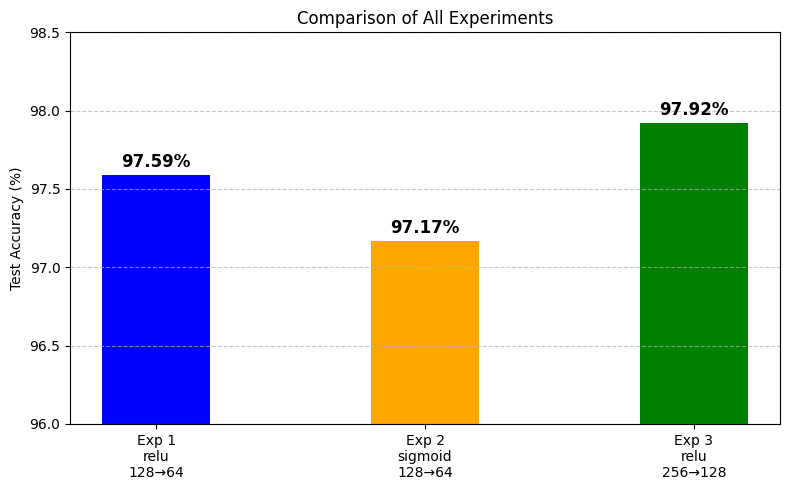

In [13]:
# Final Comparison Chart
experiments = ['Exp 1\nrelu\n128→64', 'Exp 2\nsigmoid\n128→64', 'Exp 3\nrelu\n256→128']
accuracies = [97.59, 97.17, 97.92]
colors = ['blue', 'orange', 'green']

plt.figure(figsize=(8, 5))
bars = plt.bar(experiments, accuracies, color=colors, width=0.4)

# اكتب الأرقام فوق كل عمود
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{acc}%', ha='center', fontsize=12, fontweight='bold')

plt.ylim(96, 98.5)
plt.ylabel('Test Accuracy (%)')
plt.title('Comparison of All Experiments')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()